# Figure 1 — forcing resolution changes variance, not the mean

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

SITE = "Flanagan"
YEAR = 2010
SAVE = False

# NB: the postprocessed data spans 2001-2010 for every case. `annual` (one value per
# year) is available but intentionally not plotted here; `longterm` is the single 2001-2010
# mean, repeated at every year-end so it lines up with the other cases' time index.
CASES = ["hourly", "daily", "monthly", "longterm"]
LABELS = {"hourly": "hourly", "daily": "daily", "monthly": "monthly", "longterm": "long-term mean"}
COLORS = dict(zip(CASES, ["#a6c8ec", "#3f8fe3", "#1857a9", "#0c2d61"]))

STORE = ("s3://carbonplan-carbon-removal/ew-workflows-data/min3p/simulations"
         "/postprocessed/met_forcing_rxn")

# Full 2001-2010 record per case (used for the box-and-whisker distributions).
full = {c: xr.open_zarr(f"{STORE}/clim_dat_{SITE}_{c}.zarr") for c in CASES}
# Single selected year per case (used for the time-series lines).
data = {c: full[c].sel(time=str(YEAR)) for c in CASES}

# `monthly`/`longterm` label each bin at its end, padded.
YEAR_START, YEAR_END = np.datetime64(f"{YEAR}-01-01"), np.datetime64(f"{YEAR + 1}-01-01")


def year_line(c, var):
    t = data[c]["time"].to_numpy()
    y = data[c][var].to_numpy()
    t = np.concatenate([[YEAR_START], t, [YEAR_END]])
    y = np.concatenate([y[:1], y, y[-1:]])
    return t, y

In [26]:
def plot_var(var, ylabel, symlog=False):
    fig, (ts, box) = plt.subplots(1, 2, figsize=(9.5, 3), width_ratios=[3, 1.4], tight_layout=True)

    for c in CASES:
        t, y = year_line(c, var)
        ts.plot(t, y, color=COLORS[c], lw=1.2, label=LABELS[c])
    ts.set_ylabel(ylabel)
    ts.set_title(f"{SITE}, {YEAR}")
    ts.legend(frameon=False, fontsize=8)
    if symlog:
        ts.set_yscale("symlog")

    vals = [full[c][var].to_numpy() for c in CASES]
    bp = box.boxplot(vals, tick_labels=[LABELS[c] for c in CASES], showmeans=True, meanline=True,
                      meanprops=dict(color="k", lw=1.5),
                      flierprops=dict(marker=".", ms=3, alpha=0.3, mec="none", mfc="0.4"))
    for line, c in zip(bp["boxes"], CASES):
        line.set_color(COLORS[c])
    box.tick_params(axis="x", rotation=45)
    if symlog:
        box.set_yscale("symlog")
    box.set_title("mean flat, spread shrinks", fontsize=10)
    return fig

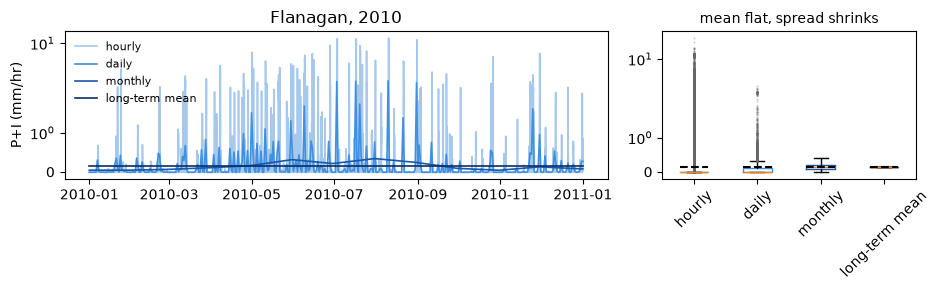

In [27]:
fig_pi = plot_var("p_plus_i", "P+I (mm/hr)", symlog=True)

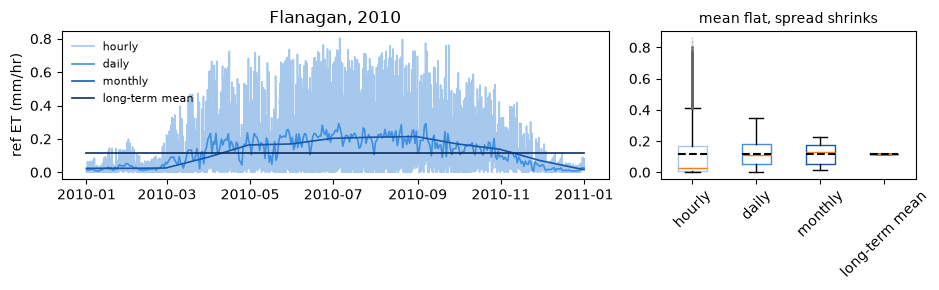

In [28]:
fig_et = plot_var("ref_et", "ref ET (mm/hr)", symlog=False)

In [5]:
if SAVE:
    for fig, name in [(fig_pi, "fig1_p_plus_i"), (fig_et, "fig1_ref_et")]:
        fig.savefig(f"{name}.pdf")
        fig.savefig(f"{name}.png", dpi=300)